# Repairing discrete no-arbitrage violations

This notebook explains how `helper_module.arbitrage_repair` moves **prices** or **Black–76 implied vols** on a finite grid to the **nearest** (in a precise sense below) surface that satisfies the same **necessary** conditions as in `arbitrage.py`:
- **Strike slice (fixed expiry):** call prices decreasing in $K$, and **butterfly / convexity** in $K$.
- **Calendar (vol surface):** total variance $w(K,T)=\sigma^2 T$ non-decreasing in $T$ along each strike row.

In [1]:
import sys
from pathlib import Path

_root = Path.cwd().resolve()
for _base in [_root, *_root.parents]:
    if (_base / "helper_module").is_dir() and (_base / "pyproject.toml").is_file():
        if str(_base) not in sys.path:
            sys.path.insert(0, str(_base))
        break
else:
    raise RuntimeError("Run from repo root or install with pip install -e .")

import numpy as np
import matplotlib.pyplot as plt

from helper_module.arbitrage import validate_price_surface, validate_vol_surface
from helper_module.arbitrage_repair import (
    project_call_prices_l2,
    repair_price_surface,
    repair_vol_surface_black76,
)
from helper_module.black76 import black76_price

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "sans-serif"]})

## 1. One expiry: $L^2$ projection of call prices

For a fixed maturity, no static arbitrage implies the **call price vector** $C \in \mathbb{R}^n$ (sorted strikes) lies in a **convex polyhedron** defined by linear inequalities:
- $C_i \ge C_{i+1}$ (calls decrease with strike),
- $C_{i-1} - 2C_i + C_{i+1} \ge 0$ (discrete convexity / butterfly).

We define the **repair** as the **Euclidean projection** of a noisy vector $C^{\mathrm{obs}}$ onto that set:

$$C^{\star} = \arg\min_{C \in \mathcal{P}} \|C - C^{\mathrm{obs}}\|_2^2.$$

This convex quadratic program is solved with `scipy.optimize.minimize` (SLSQP). It is the closest point in $\mathcal{P}$ in **$L^2$**; other norms would give different projections.

Valid before bump? True
Valid after bump? False
Projection L2 distance: 0.0011095593385059262
Valid after projection? True


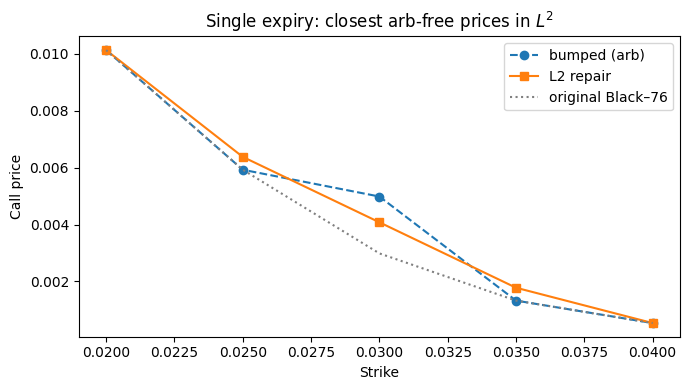

In [2]:
forward = 0.03
strikes = np.array([0.02, 0.025, 0.03, 0.035, 0.04])
T = 1.0
sigma = 0.25
p0 = np.array([black76_price(forward, k, T, sigma, 1.0, "call") for k in strikes])
p_bad = p0.copy()
p_bad[2] += 0.002  # break butterfly at interior strike

print("Valid before bump?", validate_price_surface(strikes, np.full_like(strikes, T), p0).ok)
print("Valid after bump?", validate_price_surface(strikes, np.full_like(strikes, T), p_bad).ok)

p_rep = project_call_prices_l2(p_bad)
print("Projection L2 distance:", np.linalg.norm(p_rep - p_bad))
print("Valid after projection?", validate_price_surface(strikes, np.full_like(strikes, T), p_rep).ok)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(strikes, p_bad, "o--", label="bumped (arb)")
ax.plot(strikes, p_rep, "s-", label="L2 repair")
ax.plot(strikes, p0, ":", color="gray", label="original Black–76")
ax.set_xlabel("Strike")
ax.set_ylabel("Call price")
ax.legend()
ax.set_title("Single expiry: closest arb-free prices in $L^2$")
plt.tight_layout()
plt.show()

## 2. Calendar: cumulative maximum on total variance $w=\sigma^2 T$

A common **necessary** condition on a Black-implied vol grid is that **total variance** $w(K,T)=\sigma(K,T)^2\,T$ be **non-decreasing** in $T$ at each strike (no calendar arbitrage in the sense of total variance).

If $w$ drops when $T$ increases, a minimal **pointwise** repair is the **cumulative maximum** along $T$:

$$\tilde w(K, T_j) = \max_{k \le j} w(K, T_k).$$

This is the **isotonic regression** of $w$ with respect to $T$ with a **chain** constraint (increasing). It is **not** the $L^2$-closest increasing $w$ to the observed $w$ (that would be a different QP); it is the smallest **upward** move in $w$ at each node that restores monotonicity — often used as a fast calendar filter.

Then $\tilde\sigma = \sqrt{\tilde w / T}$.

## 3. Full vol surface: alternate calendar + strike repair

Calendar repair (cummax on $w$) and strike-slice repair (projection on prices) **do not commute**. The function `repair_vol_surface_black76` **iterates**:

1. $w \leftarrow \mathrm{cummax}_T(w)$, $\sigma \leftarrow \sqrt{w/T}$.
2. Build Black–76 prices; **per expiry column**, $L^2$-project prices onto the strike polyhedron.
3. Invert Black–76 to get new $\sigma$.
4. Stop when `validate_vol_surface` passes or `max_iter` is reached.

In practice this often converges in a few steps on small grids.

In [ ]:
def example_bad_calendar(forward: float):
    strikes = np.array([0.02, 0.025, 0.03, 0.035, 0.04])
    Ts = np.array([0.5, 1.0, 2.0])
    ok_sig, bad_long = 0.25, 0.08
    s, e, v = [], [], []
    for t in Ts:
        sig = bad_long if t >= 2.0 - 1e-9 else ok_sig
        for k in strikes:
            s.append(k)
            e.append(t)
            v.append(sig)
    return np.array(s), np.array(e), np.array(v)


s, e, sig0 = example_bad_calendar(forward)
print("Before repair:", validate_vol_surface(s, e, sig0, forward).ok)
sr, er, sigr, rep = repair_vol_surface_black76(s, e, sig0, forward, tol=1e-8)
print("After repair:", rep.ok, "iterations:", rep.iterations)
print("Frobenius L2 change in sigma matrix:", rep.l2_delta)

Before repair: False
After repair: True iterations: 1
Frobenius L2 change in sigma matrix: 0.21639926932840917


## 4. Limitations

- **Discrete grid only:** conditions are checked on given strikes/expiries; they say nothing about arbitrage **between** nodes after arbitrary interpolation.
- **Black–76:** repair in vol space uses Black inversion; other conventions (normal/Bachelier) would need a parallel routine.
- **Joint optimality:** alternating cummax + per-column projection is **not** guaranteed to minimize a single global $L^2$ distance in $\sigma$ over all constraints simultaneously; it is a practical **heuristic** that works well when violations are small.

For production surfaces, people often parameterize (e.g. SVI) with **built-in** no-arbitrage constraints, then fit parameters.